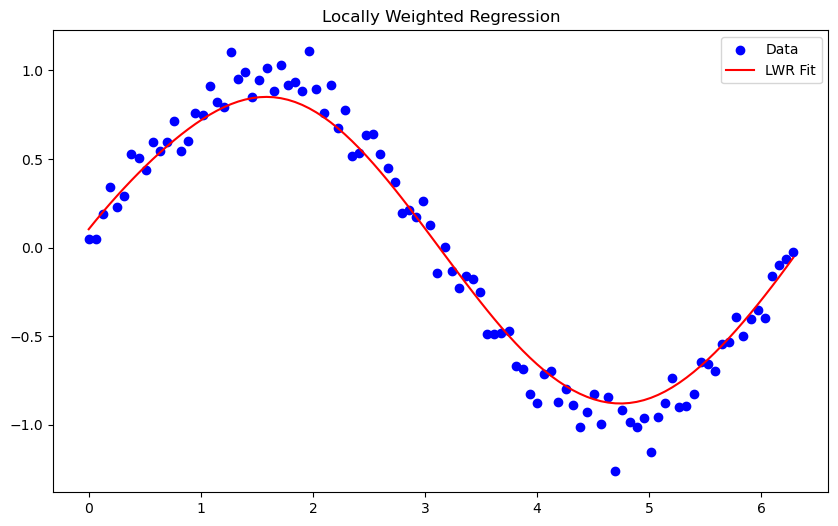

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 🔹 Gaussian Kernel (weight function)
def gaussian_kernel(x, xi, tau):
    return np.exp(-np.sum((x - xi)**2) / (2 * tau**2))

# 🔹 Locally Weighted Regression
def locally_weighted_regression(x, X, y, tau):
    m = X.shape[0]
    
    # Compute weights
    weights = np.array([gaussian_kernel(x, X[i], tau) for i in range(m)])
    W = np.diag(weights)
    
    # Theta calculation
    XTW = X.T @ W
    theta = np.linalg.pinv(XTW @ X) @ XTW @ y
    
    # Prediction
    return x @ theta

# -----------------------------
# Generate Data
# -----------------------------
np.random.seed(42)

X = np.linspace(0, 2*np.pi, 100)
y = np.sin(X) + 0.1 * np.random.randn(100)

# Add bias term
X_bias = np.c_[np.ones(X.shape), X]

# -----------------------------
# Prediction
# -----------------------------
tau = 0.5

y_pred = np.array([
    locally_weighted_regression(X_bias[i], X_bias, y, tau)
    for i in range(len(X))
])

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Data')
plt.plot(X, y_pred, color='red', label='LWR Fit')
plt.legend()
plt.title("Locally Weighted Regression")
plt.show()